# Exercise 1: Markov chain

Write a code to analyze a discrete-time Markov Chain with 5 states (S = (0,1,2,3,4)) using 2 methods.

**Method 1**: Stochastic Simulation

Simulate the chain for large $n$ steps by randomly picking the next state based on the transition probabilities.

Tasks:
*	Plot a frequence of the state occurrences.
*	Calculate the **theoretical steady-state probability** and compare the simulated result with the theoretical value.
*	Determine the **final mean observable** and compare the simulated result with the theoretical value.

**Method 2**: Matrix Iteration

Use the formula
$P_{t+1} = P_t \times T$ or $P_{t+1} = T^T \times P_t$ where $P_{t}$ is the probability disttribution vector at the step t. 

*	Compare the resulting distribution and mean observable with the results from Method 1.
*	Why is the final distribution uniform ?
The transition probabilities are defined as:

$T(s_i \rightarrow s_j) = 1/3$ if $j=i\pm 1$ or $j =i$. 


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

## Building the transition matrix

The chain has 5 states with periodic boundary conditions (state 0 is adjacent to state 4). Each state can transition to itself or its two neighbours with equal probability 1/3.
The matrix entry T[i, j] gives the probability of moving **from** state i **to** state j.

In [2]:
N_states = 5

# Build T where T[i,j] = probability of going from state i to state j.
# Each state connects to itself and its two neighbours (periodic boundaries).
T = np.zeros((N_states, N_states))
for i in range(N_states):
    neighbors = [(i - 1) % N_states, i, (i + 1) % N_states]
    for j in neighbors:
        T[i, j] = 1 / 3

print('Transition matrix T (rows = from, cols = to):')
print(np.round(T, 4))
print('\nRow sums (all must be 1):', T.sum(axis=1))

Transition matrix T (rows = from, cols = to):
[[0.3333 0.3333 0.     0.     0.3333]
 [0.3333 0.3333 0.3333 0.     0.    ]
 [0.     0.3333 0.3333 0.3333 0.    ]
 [0.     0.     0.3333 0.3333 0.3333]
 [0.3333 0.     0.     0.3333 0.3333]]

Row sums (all must be 1): [1. 1. 1. 1. 1.]


## Method 1: Stochastic Simulation

In [3]:
def run_markov_chain(T, n_steps, start_state=0):
    """Simulate the Markov chain for n_steps steps."""
    states = np.arange(T.shape[0])
    history = np.empty(n_steps, dtype=int)
    current = start_state
    for t in range(n_steps):
        history[t] = current
        # pick next state according to row i of T
        current = np.random.choice(states, p=T[current])
    return history

N_STEPS = 100000
history = run_markov_chain(T, N_STEPS, start_state=0)

# Count how many times each state was visited
counts = np.bincount(history, minlength=N_states)
simulated_prob = counts / N_STEPS

# Theoretical steady-state: uniform 1/5 for each state
theoretical_prob = np.full(N_states, 1 / N_states)

print(f'Simulated  distribution: {np.round(simulated_prob, 4)}')
print(f'Theoretical distribution: {np.round(theoretical_prob, 4)}')

Simulated  distribution: [0.2001 0.2016 0.2013 0.1986 0.1985]
Theoretical distribution: [0.2 0.2 0.2 0.2 0.2]


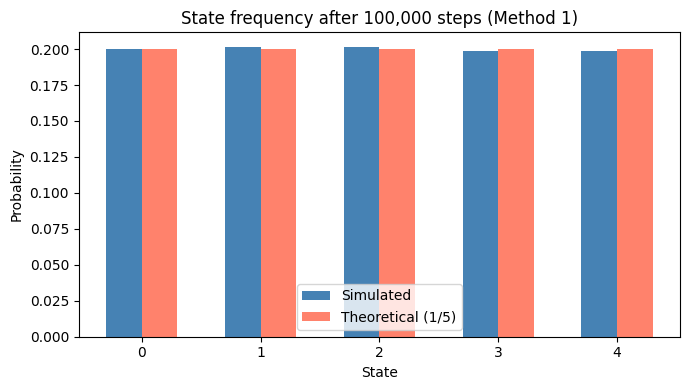

In [4]:
# Plot the frequency of state occurrences
fig, ax = plt.subplots(figsize=(7, 4))
x = np.arange(N_states)
ax.bar(x - 0.15, simulated_prob, width=0.3, label='Simulated', color='steelblue')
ax.bar(x + 0.15, theoretical_prob, width=0.3, label='Theoretical (1/5)', color='tomato', alpha=0.8)
ax.set_xlabel('State')
ax.set_ylabel('Probability')
ax.set_title(f'State frequency after {N_STEPS:,} steps (Method 1)')
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.savefig('ex1_method1_freq.png', dpi=120)
plt.show()

In [5]:
simulated_mean = np.mean(history)

# Theoretical mean = sum over states of state * P_eq(state)
# = (0 + 1 + 2 + 3 + 4) * (1/5) = 2.0
theoretical_mean = np.sum(np.arange(N_states) * theoretical_prob)

print(f'Simulated  mean observable: {simulated_mean:.4f}')
print(f'Theoretical mean observable: {theoretical_mean:.4f}')

Simulated  mean observable: 1.9938
Theoretical mean observable: 2.0000


## Method 2: Matrix Iteration

Starting from an arbitrary initial distribution, we repeatedly apply $P_{t+1} = P_t \cdot T$ until the distribution converges to the equilibrium.

In [18]:
# Start from a highly non-uniform distribution
P = np.array([0.0, 0.0, 0.0, 0.0, 1.0])

n_iter = 10
history_matrix = [P.copy()]

for _ in range(n_iter):
    P = P @ T  # row-vector convention: P_{t+1} = P_t * T
    history_matrix.append(P.copy())

print('Distribution after matrix iteration:')
print(np.round(P, 6))
print('Theoretical:', np.round(theoretical_prob, 6))

Distribution after matrix iteration:
[0.200257 0.199326 0.199326 0.200257 0.200833]
Theoretical: [0.2 0.2 0.2 0.2 0.2]


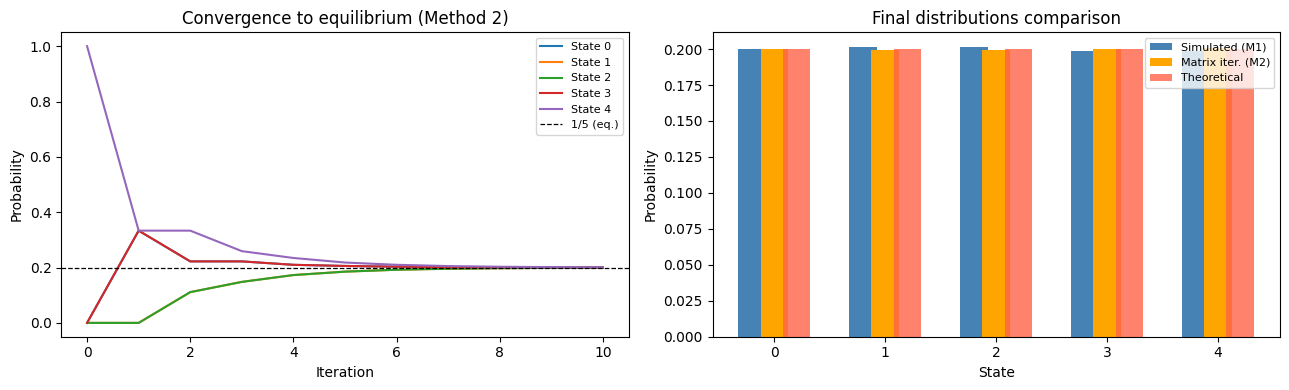

Mean observable (matrix): 2.0021
Mean observable (simul.) : 1.9938
Theoretical mean         : 2.0000


In [19]:
# Plot how each state probability evolves over iterations
history_matrix = np.array(history_matrix)
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: convergence curves
ax = axes[0]
for s in range(N_states):
    ax.plot(history_matrix[:, s], label=f'State {s}')
ax.axhline(1/5, color='k', linestyle='--', linewidth=0.9, label='1/5 (eq.)')
ax.set_xlabel('Iteration')
ax.set_ylabel('Probability')
ax.set_title('Convergence to equilibrium (Method 2)')
ax.legend(fontsize=8)

# Right: final bar chart vs simulated result
ax2 = axes[1]
x = np.arange(N_states)
ax2.bar(x - 0.2, simulated_prob, width=0.25, label='Simulated (M1)', color='steelblue')
ax2.bar(x,       P,              width=0.25, label='Matrix iter. (M2)', color='orange')
ax2.bar(x + 0.2, theoretical_prob, width=0.25, label='Theoretical', color='tomato', alpha=0.8)
ax2.set_xlabel('State')
ax2.set_ylabel('Probability')
ax2.set_title('Final distributions comparison')
ax2.set_xticks(x)
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig('ex1_method2_iter.png', dpi=120)
plt.show()

# Mean observable from matrix result
matrix_mean = np.sum(np.arange(N_states) * P)
print(f'Mean observable (matrix): {matrix_mean:.4f}')
print(f'Mean observable (simul.) : {simulated_mean:.4f}')
print(f'Theoretical mean         : {theoretical_mean:.4f}')

### Why is the final distribution uniform?

The transition matrix $T$ was constructed with periodic boundary conditions and equal probability $1/3$ for all three possible moves. This means every state has exactly the same 'role' in the chain — the matrix is **doubly stochastic** (columns also sum to 1). By the Birkhoff–von Neumann theorem, the unique stationary distribution of a doubly stochastic, ergodic Markov chain is the **uniform distribution** $P_{eq}(s_i) = 1/N$. We can verify this directly: substituting $P_i = 1/5$ into the equilibrium condition $\sum_\mu P(s_\mu)\,T(s_\mu \to s_\nu) = P(s_\nu)$ gives $\frac{1}{3}(\frac{1}{5} + \frac{1}{5} + \frac{1}{5}) = \frac{1}{5}$, consistent with the lecture derivation.

## Exercise 2: Generate the desired distribution
Use 2 methods: MCMC and the transition matrix
1. Choose desired discrete probability distribution $P$
2. Compute acceptance matrix $$A(i,j) = min(1,\dfrac{P(j)}{P(i)})$$

**Method 1**: Stochastic simulation

3. Choose an initial random state $s_i$
3. Yield a proposed state $s_j$ with probability $p$.
4. Compare $p$ and $A(i \rightarrow j)$:
+ $p<= A(i \rightarrow j)$ : accept $s_j$
+ $p > A(i \rightarrow j)$ : reject, keep same state $s_i$
5. Repeat this procedure and compute equilibrium probability $P^{eq}$.

**Method 2**: Transition matrix

3. Compute transition matrix and use matrix iteration $$T(i,j) = g(i,j) A(i,j) , i \neq j$$
$$T(i,j) = g(i,j) A(i,j) + \sum_{k \neq i} g(i,k)(1-A(i,k)) , i = j$$
where we choose $g$ is uniform distribution, i.e $g(i \rightarrow j) = 1/N$ for all $i,j$. 

Repeat all the tasks of exercise 2 for the desired continuous distribution.

### Discrete distribution

In [8]:
# Choose a non-trivial target discrete distribution over 5 states.
# I picked something clearly non-uniform so the MCMC result is easy to verify visually.
P_target = np.array([0.05, 0.10, 0.40, 0.30, 0.15])
assert np.isclose(P_target.sum(), 1.0), 'P_target must be normalised'

N_d = len(P_target)
print('Target distribution P:', P_target)

Target distribution P: [0.05 0.1  0.4  0.3  0.15]


In [9]:
A = np.zeros((N_d, N_d))
for i in range(N_d):
    for j in range(N_d):
        A[i, j] = min(1.0, P_target[j] / P_target[i])

print('Acceptance matrix A:')
print(np.round(A, 3))

Acceptance matrix A:
[[1.    1.    1.    1.    1.   ]
 [0.5   1.    1.    1.    1.   ]
 [0.125 0.25  1.    0.75  0.375]
 [0.167 0.333 1.    1.    0.5  ]
 [0.333 0.667 1.    1.    1.   ]]


#### Method 1: MCMC stochastic simulation

In [10]:
def mcmc_discrete(P_target, A, n_steps):
    """Run Metropolis-Hastings MCMC for a discrete target distribution."""
    N = len(P_target)
    states_visited = np.empty(n_steps, dtype=int)
    current = np.random.randint(N)  # random start state

    for t in range(n_steps):
        states_visited[t] = current
        # Propose a new state uniformly at random
        proposed = np.random.randint(N)
        # Draw a uniform random number to decide acceptance
        u = np.random.rand()
        if u <= A[current, proposed]:
            current = proposed  # accept
        # else: reject -> stay at current (already stored)

    return states_visited

N_STEPS_2 = 200000
mcmc_history = mcmc_discrete(P_target, A, N_STEPS_2)

mcmc_counts = np.bincount(mcmc_history, minlength=N_d)
P_mcmc = mcmc_counts / N_STEPS_2

print('MCMC result  :', np.round(P_mcmc, 4))
print('Target P     :', P_target)

MCMC result  : [0.05   0.0998 0.3986 0.3012 0.1505]
Target P     : [0.05 0.1  0.4  0.3  0.15]


#### Method 2: Transition matrix iteration for MCMC

In [11]:
# Build the transition matrix using uniform proposal g(i,j) = 1/N
g = np.full((N_d, N_d), 1 / N_d)

T_mcmc = np.zeros((N_d, N_d))
for i in range(N_d):
    for j in range(N_d):
        if i != j:
            T_mcmc[i, j] = g[i, j] * A[i, j]
    # Diagonal: probability of staying due to all possible rejections
    T_mcmc[i, i] = g[i, i] * A[i, i] + np.sum(
        [g[i, k] * (1 - A[i, k]) for k in range(N_d) if k != i]
    )

print('Row sums of T_mcmc (must all be 1):', np.round(T_mcmc.sum(axis=1), 6))

# Iterate from a random initial distribution
P_iter = np.ones(N_d) / N_d  # start uniform
for _ in range(5000):
    P_iter = P_iter @ T_mcmc

print('Matrix iteration result:', np.round(P_iter, 4))
print('Target P               :', P_target)

Row sums of T_mcmc (must all be 1): [1. 1. 1. 1. 1.]
Matrix iteration result: [0.05 0.1  0.4  0.3  0.15]
Target P               : [0.05 0.1  0.4  0.3  0.15]


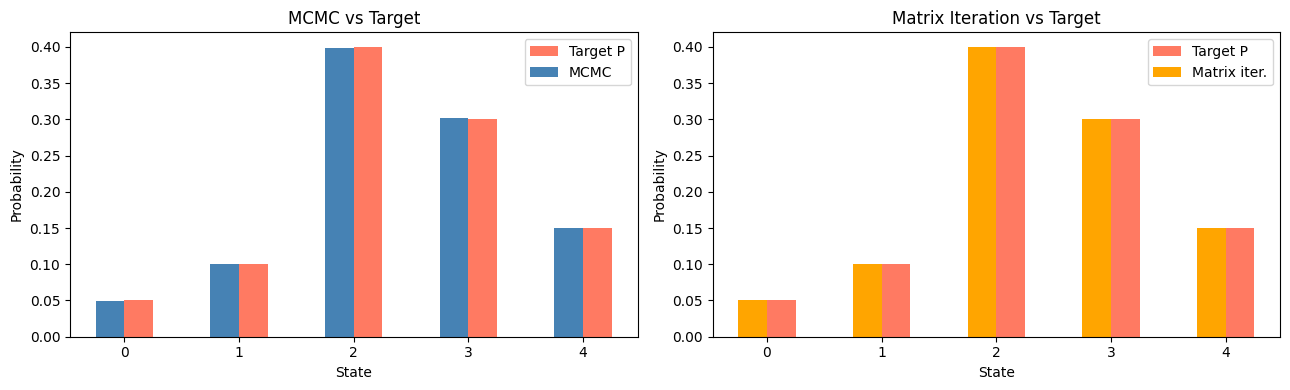

Mean - Target   : 2.4000
Mean - MCMC     : 2.4025
Mean - Matrix   : 2.4000


In [12]:
# Comparison plot for discrete distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
x = np.arange(N_d)
width = 0.25

for ax, title in zip(axes, ['MCMC vs Target', 'Matrix Iteration vs Target']):
    ax.bar(x + width, P_target, width=width, label='Target P', color='tomato', alpha=0.85)
    ax.set_xlabel('State')
    ax.set_ylabel('Probability')
    ax.set_title(title)
    ax.set_xticks(x + width / 2)
    ax.set_xticklabels(range(N_d))

axes[0].bar(x, P_mcmc,  width=width, label='MCMC', color='steelblue')
axes[1].bar(x, P_iter,  width=width, label='Matrix iter.', color='orange')
for ax in axes:
    ax.legend()

plt.tight_layout()
plt.savefig('ex2_discrete_comparison.png', dpi=120)
plt.show()

# Mean observables
obs = np.arange(N_d)
print(f'Mean - Target   : {np.dot(obs, P_target):.4f}')
print(f'Mean - MCMC     : {np.dot(obs, P_mcmc):.4f}')
print(f'Mean - Matrix   : {np.dot(obs, P_iter):.4f}')

### Continuous distribution (Metropolis algorithm)

We now apply the same Metropolis accept/reject logic to a **continuous** target distribution. I choose a standard Gaussian $P(x) \propto e^{-x^2/2}$ as the target and propose new states via a symmetric Gaussian step $x_{\text{new}} = x_{\text{cur}} + \delta\,\mathcal{N}(0,1)$. The acceptance probability is $A = \min(1,\, P(x_{\text{new}})/P(x_{\text{cur}}))$.

In [20]:
def gaussian_target(x, mu=0.0, sigma=1.0):
    """Unnormalised Gaussian — only the ratio P(x_new)/P(x_cur) is needed."""
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)


def metropolis_continuous(target, n_steps, step_size=1.0, x0=0.0):
    """Metropolis sampler for a 1-D continuous target distribution."""
    samples = np.empty(n_steps)
    x_cur = x0
    n_accepted = 0

    for t in range(n_steps):
        samples[t] = x_cur
        # Symmetric Gaussian proposal
        x_new = x_cur + step_size * np.random.randn()
        # Metropolis acceptance ratio
        ratio = target(x_new) / target(x_cur)
        if np.random.rand() <= min(1.0, ratio):
            x_cur = x_new
            n_accepted += 1

    acceptance_rate = n_accepted / n_steps
    return samples, acceptance_rate


N_CONT = 2000000
STEP = 1.0
samples_cont, acc_rate = metropolis_continuous(gaussian_target, N_CONT, step_size=STEP)
print(f'Acceptance rate: {acc_rate:.3f}')
print(f'Sample mean : {samples_cont.mean():.4f}  (expected 0.0)')
print(f'Sample std  : {samples_cont.std():.4f}  (expected 1.0)')

Acceptance rate: 0.704
Sample mean : -0.0044  (expected 0.0)
Sample std  : 0.9995  (expected 1.0)


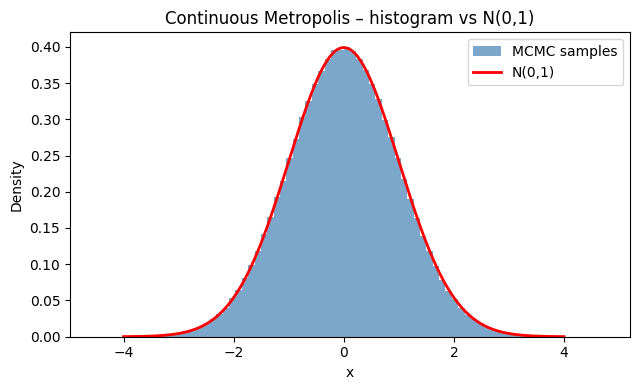

In [21]:
plt.figure(figsize=(6.5, 4))

plt.hist(samples_cont, bins=80, density=True, color='steelblue',
         alpha=0.7, label='MCMC samples')

xs = np.linspace(-4, 4, 300)
gauss_pdf = (1 / np.sqrt(2 * np.pi)) * np.exp(-xs**2 / 2)
plt.plot(xs, gauss_pdf, 'r-', lw=2, label='N(0,1)')

plt.xlabel('x')
plt.ylabel('Density')
plt.title('Continuous Metropolis – histogram vs N(0,1)')
plt.legend()

plt.tight_layout()
plt.savefig('ex2_continuous_metropolis.png', dpi=120)
plt.show()

#### Comparing mean and variance with theoretical values

For the standard Gaussian $\mathcal{N}(0,1)$ the theoretical mean is $\mu = 0$ and variance is $\sigma^2 = 1$. We also check the mean of $x^2$ which equals 1.

In [27]:
# Burn-in: discard the first few thousand steps to let the chain equilibrate
burn_in = 1000
samples_eq = samples_cont[burn_in:]

print('After burn-in:')
print(f'  <x>      = {samples_eq.mean():.5f}  (theoretical: 0.0)')
print(f'  <x^2>    = {(samples_eq**2).mean():.5f}  (theoretical: 1.0)')
print(f'  std(x)   = {samples_eq.std():.5f}  (theoretical: 1.0)')

After burn-in:
  <x>      = -0.00441  (theoretical: 0.0)
  <x^2>    = 0.99909  (theoretical: 1.0)
  std(x)   = 0.99954  (theoretical: 1.0)
